# Radio Occultation Validation: COSMIC-2 and GPS

This notebook validates the radio occultation (RO) analysis in TAT-C (`collect_ro_observations`, see the [GNSS Radio Occultation](../examples/CollectRO.ipynb) example) against the [COSMIC-2](https://www.cosmic.ucar.edu/what-we-do/cosmic-2) constellation receiving GPS signals on 14 May 2026.

**Part 1** asks how the tangent point should be defined. TAT-C originally used a *geocentric* tangent point, the point on the straight transmitter–receiver line closest to Earth's center. The [limb sounding validation](ValidateLimbMLS.ipynb) showed that the *ellipsoidal* tangent point, the point on the line with minimum WGS 84 geodetic altitude, matches operational geolocation far better for limb sounders. Part 1 measures what the same change means for RO, using recorded COSMIC-2 and GPS positions rather than propagated orbits, so that orbit errors play no part. Based on these results, TAT-C now uses the ellipsoidal tangent point; the geocentric definition is kept here for comparison as the *previous* TAT-C definition.

1. **Size of the change.** For real COSMIC-2/GPS geometries, how far does the tangent point move, and how much do its height and timing change?
2. **Operational convention.** Which definition matches the tangent point geolocation in operationally processed COSMIC-2 data?
3. **Practical significance.** How does the change compare with the difference between TAT-C's representative point (the straight-line tangent point at `sample_elevation`, -80 km by default) and the reported location of each occultation?

**Part 2** runs `collect_ro_observations` end to end with orbits for the same day and compares its predictions with every GPS occultation COSMIC-2 recorded:

4. **Orbits.** How closely do published orbits reproduce the recorded satellite positions?
5. **Predicted and observed occultations.** Does TAT-C predict the occultations that were observed, and how many more?
6. **Detection.** Which predicted occultations were actually recorded, and why not the others?
7. **Timing and location.** How accurate are the time and position TAT-C reports for each matched occultation?

## Reference Data

GNSS RO data from several missions and processing centers are available in the [AWS Registry of Open Data](https://registry.opendata.aws/gnss-ro-opendata/) (no account required), with a metadata database that the [`awsgnssroutils`](https://pypi.org/project/awsgnssroutils/) package can query (`pip install awsgnssroutils netCDF4`). This notebook uses UCAR's COSMIC-2 processing for 14 May 2026 (the most recent complete day with data files when this analysis was performed):

* **calibratedPhase** (Level 1A): receiver and GPS positions in Earth-centered, Earth-fixed coordinates, sampled at 100 Hz through each occultation (GPS positions at the time of signal transmission).
* **refractivityRetrieval** (Level 2A): the retrieved profile, with the tangent point latitude and longitude at every altitude level and a reference location for the occultation.

The full day contains about 2,400 GPS occultations with both files. The Level 1A files are about 4 MB each, so a seeded random sample of 200 occultations (about 0.9 GB) is used, downloaded once to a local `data/ro` directory.

In [1]:
import json
import os

import numpy as np
from awsgnssroutils.database import RODatabaseClient

DATA_DIR = os.path.join("data", "ro")
rodb = RODatabaseClient(metadata_root=os.path.join(DATA_DIR, "metadata"), version="v1.1")
occultations = rodb.query(
    missions="cosmic2", datetimerange=("2026-05-14", "2026-05-14T23:59:59"), silent=True
)
gps = occultations.filter(
    GNSSconstellations="G",
    availablefiletypes=["ucar_calibratedPhase", "ucar_refractivityRetrieval"],
)
rng = np.random.default_rng(20260514)
sample = gps[0:0]
sample._data = [gps._data[i] for i in sorted(rng.choice(gps.size, 200, replace=False))]
sample.size = len(sample._data)
for file_type in ["ucar_calibratedPhase", "ucar_refractivityRetrieval"]:
    # flat layout keeps local paths short (Windows limits paths to 260 characters)
    sample.download(file_type, data_root=DATA_DIR, keep_aws_structure=False, silent=True)
print(f"{occultations.size} COSMIC-2 occultations on 14 May 2026, {gps.size} from GPS with both files, {sample.size} sampled")

5710 COSMIC-2 occultations on 14 May 2026, 2441 from GPS with both files, 200 sampled


## Part 1: Tangent Point Definitions

For a receiver at $x_{rx}$ and transmitter at $x_{tx}$ (both Earth-fixed), the straight line is $x_{rx} + s\hat{d}$ with $\hat{d} = (x_{tx} - x_{rx}) / ||x_{tx} - x_{rx}||$.

* **Geocentric** (previous TAT-C): the point closest to Earth's center, $s^* = -x_{rx} \cdot \hat{d}$.
* **Ellipsoidal** (TAT-C): the point of minimum WGS 84 geodetic altitude, computed with TAT-C's own `_ellipsoidal_tangent_point` (the routine `collect_ro_observations` uses). Scaling the polar axis by $k = (a + h)/(b + h)$ turns the surface of constant geodetic altitude $h$ into very nearly a sphere, so $s^*$ is the closest approach of the scaled line to the origin. Since the tangent height $h$ is an output for RO rather than a requested input, $k$ is evaluated at the current height estimate and refined three times, starting from the geocentric point.

For comparison, a third definition uses the *local center of curvature* that UCAR reports with each retrieval: the closest approach of the line to that point.

In [2]:
import netCDF4 as nc
import pandas as pd
from pyproj import Geod, Transformer

from tatc.analysis.tangent_point import _ellipsoidal_tangent_point, _geodetic_altitude, _itrs_rotation
from tatc.constants import timescale

GEOD = Geod(ellps="WGS84")
TO_LLA = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
DEFINITIONS = ["geocentric", "ellipsoidal", "curvature"]


def to_lla(p):
    """Geodetic longitude (deg), latitude (deg), and altitude (m) of Earth-fixed positions (3, N)."""
    return tuple(np.asarray(x) for x in TO_LLA.transform(p[0], p[1], p[2]))


def tangent_points(rx, tx, t, center_of_curvature=np.zeros(3)):
    """Straight-line tangent points (Earth-fixed, m) under each definition, for
    Earth-fixed receiver and transmitter positions (3, N) at Skyfield times t."""
    d = (tx - rx) / np.linalg.norm(tx - rx, axis=0)
    points = {"geocentric": rx - np.einsum("ij,ij->j", rx, d) * d}
    # TAT-C's ellipsoidal tangent point, which works in the inertial (GCRS) frame
    rotation = _itrs_rotation(t)
    to_gcrs = lambda p: np.einsum("jin,jn->in", rotation, p)  # noqa: E731
    tp = _ellipsoidal_tangent_point(to_gcrs(rx), to_gcrs(tx - rx), t)
    points["ellipsoidal"] = np.einsum("ijn,jn->in", rotation, tp)
    rx_c = rx - center_of_curvature[:, np.newaxis]
    points["curvature"] = rx - np.einsum("ij,ij->j", rx_c, d) * d
    return points


def crossing(t, h, value):
    """Time at which h(t) first crosses value (linear interpolation), or NaN."""
    c = np.nonzero(np.diff(np.sign(h - value)))[0]
    if len(c) == 0:
        return np.nan
    j = c[0]
    return t[j] + (value - h[j]) / (h[j + 1] - h[j]) * (t[j + 1] - t[j])


def interpolate(t, p, times):
    return np.array([np.interp(times, t, p[i]) for i in range(3)])


def load(record, step=10):
    """Receiver/transmitter positions (subsampled to 10 Hz) and retrieved tangent points of one occultation."""
    l1 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_calibratedPhase"])))
    l1.set_auto_mask(False)
    t, rx, tx = l1["time"][:], l1["positionLEO"][:].T, l1["positionGNSS"][:].T
    ok = (np.abs(t) < 1e10) & np.all(np.abs(rx) < 1e10, axis=0) & np.all(np.abs(tx) < 1e10, axis=0)
    i = np.nonzero(ok)[0][::step]
    l2 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_refractivityRetrieval"])))
    l2.set_auto_mask(False)
    return {
        "occid": record["occid"],
        "t": t[i],
        "start": float(l1["startTime"][...]),
        # GPS seconds since 1980-01-06 are TAI - 19 s
        "ts": timescale.tai_jd(2444244.5 + (float(l1["startTime"][...]) + t[i] + 19) / 86400),
        "rx": rx[:, i],
        "tx": tx[:, i],
        "center_of_curvature": l2["centerOfCurvature"][:].astype(float),
        "levels": pd.DataFrame(
            {name: l2[name][:].astype(float) for name in ["altitude", "latitude", "longitude", "orientation"]}
        ),
        "ref_lat": float(l2["refLatitude"][...]),
        "ref_lon": float(l2["refLongitude"][...]),
        "ref_time": float(l2["refTime"][...]),
    }


occs = [load(record) for record in sample._data]
for occ in occs:
    occ["points"] = tangent_points(occ["rx"], occ["tx"], occ["ts"], occ["center_of_curvature"])
    occ["lla"] = {k: to_lla(p) for k, p in occ["points"].items()}

## Test 1: Size of the Change

Every 10 Hz sample with a straight-line tangent height between -200 and +60 km (TAT-C's default `range_elevation`) is compared under the geocentric and ellipsoidal definitions. The representative point of each occultation, where the straight-line height crosses -80 km (TAT-C's default `sample_elevation`), is also compared, including the time at which it is reached.

In [3]:
rows, points = [], []
for occ in occs:
    g, e = occ["lla"]["geocentric"], occ["lla"]["ellipsoidal"]
    band = (g[2] > -200e3) & (g[2] < 60e3)
    points.append(
        pd.DataFrame(
            {
                "latitude": e[1][band],
                "shift_km": GEOD.inv(g[0][band], g[1][band], e[0][band], e[1][band])[2] / 1e3,
                "height_change_m": e[2][band] - g[2][band],
            }
        )
    )
    t80 = {k: crossing(occ["t"], occ["lla"][k][2], -80e3) for k in ["geocentric", "ellipsoidal"]}
    p80 = {k: to_lla(interpolate(occ["t"], occ["points"][k], [t80[k]])) for k in t80}
    rows.append(
        {
            "occid": occ["occid"],
            "t80_geocentric": t80["geocentric"],
            "t80_ellipsoidal": t80["ellipsoidal"],
            "lon80_geocentric": p80["geocentric"][0][0],
            "lat80_geocentric": p80["geocentric"][1][0],
            "lon80_ellipsoidal": p80["ellipsoidal"][0][0],
            "lat80_ellipsoidal": p80["ellipsoidal"][1][0],
        }
    )
points = pd.concat(points, ignore_index=True)
summary = pd.DataFrame(rows).dropna()
summary["shift80_km"] = (
    GEOD.inv(summary.lon80_geocentric, summary.lat80_geocentric, summary.lon80_ellipsoidal, summary.lat80_ellipsoidal)[2] / 1e3
)
summary["dt80_s"] = summary.t80_ellipsoidal - summary.t80_geocentric

pd.DataFrame(
    {
        "all samples: horizontal shift (km)": points.shift_km.describe(percentiles=[0.5, 0.95]),
        "all samples: height change (m)": points.height_change_m.describe(percentiles=[0.5, 0.95]),
        "-80 km point: horizontal shift (km)": summary.shift80_km.describe(percentiles=[0.5, 0.95]),
        "-80 km point: time change (s)": summary.dt80_s.describe(percentiles=[0.5, 0.95]),
    }
).T.round(3)

,count,mean,std,min,50%,95%,max
all samples: horizontal shift (km),241531.0,4.928,5.059,0.000,3.011,16.412,20.546
all samples: height change (m),241531.0,-3.874,6.958,-32.124,-0.707,-0.004,0.000
-80 km point: horizontal shift (km),199.0,4.639,4.773,0.008,2.842,15.968,19.850
-80 km point: time change (s),199.0,0.000,0.004,-0.019,-0.000,0.007,0.022


The shift is horizontal and lies along the ray. As for the limb sounders, it is near zero at the equator and grows toward middle latitudes, especially for rays oriented north-south. COSMIC-2's 24 deg orbit inclination confines its tangent points to roughly ±45 deg, where the shift peaks at about 20 km; missions in polar orbits would also sample higher latitudes, where it decreases again toward the poles. Because RO rays point in all directions, the typical shift is smaller than for MLS (whose rays run north-south). Tangent heights change by only a few meters, so the times at which profiles reach a given height, and therefore each profile's `start`, `end`, and `time`, are essentially unchanged.

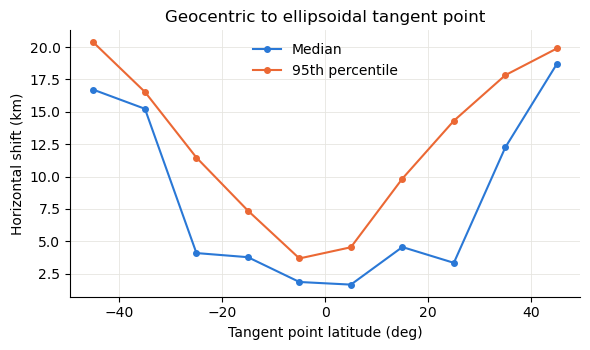

In [4]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6}
)

edges = np.arange(-90, 91, 10)
centers = (edges[1:] + edges[:-1]) / 2
binned = points.groupby(pd.cut(points.latitude, edges), observed=False).shift_km
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(centers, binned.median(), color=BLUE, marker="o", ms=4, label="Median")
ax.plot(centers, binned.quantile(0.95), color=ORANGE, marker="o", ms=4, label="95th percentile")
ax.set(xlabel="Tangent point latitude (deg)", ylabel="Horizontal shift (km)", title="Geocentric to ellipsoidal tangent point")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Test 2: Operational Convention

UCAR reports a tangent point latitude and longitude at every altitude level of each retrieved profile. Above 50 km, ray bending is small (well below 0.1 mrad), so the bent ray and the straight line nearly coincide and each retrieved tangent point can be compared directly with the straight-line tangent point *at the same geodetic height*: for each definition, the point on its tangent point track where the height equals the level's altitude. No timing information is needed.

In [5]:
rows = []
for occ in occs:
    lev = occ["levels"]
    lev = lev[(lev.altitude > 50e3) & (lev.altitude < 80e3) & (lev.latitude.abs() <= 90)].iloc[::10]
    for k in DEFINITIONS:
        t = np.array([crossing(occ["t"], occ["lla"][k][2], a) for a in lev.altitude])
        ok = np.isfinite(t)
        lon, lat, _ = to_lla(interpolate(occ["t"], occ["points"][k], t[ok]))
        rows.append(
            pd.DataFrame(
                {
                    "occid": occ["occid"],
                    "definition": k,
                    "latitude": lev.latitude[ok],
                    "distance_km": GEOD.inv(lev.longitude[ok], lev.latitude[ok], lon, lat)[2] / 1e3,
                }
            )
        )
matched = pd.concat(rows, ignore_index=True)
matched.groupby("definition").distance_km.describe(percentiles=[0.5, 0.95]).loc[DEFINITIONS].round(3)

,count,mean,std,min,50%,95%,max
definition,,,,,,,
geocentric,30013.0,4.639,4.403,0.083,3.295,14.959,19.111
ellipsoidal,30013.0,0.313,0.302,0.004,0.183,0.970,1.786
curvature,30013.0,5.033,4.663,0.032,3.895,15.342,18.152


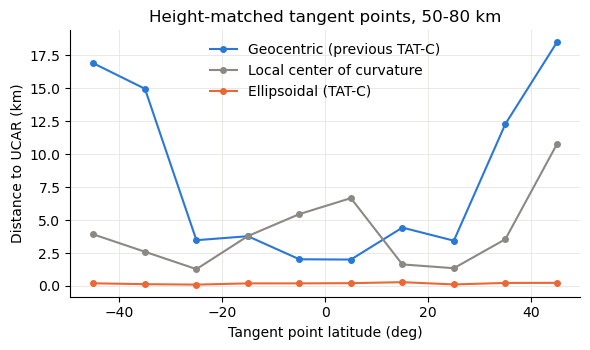

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for k, color, label in [
    ("geocentric", BLUE, "Geocentric (previous TAT-C)"),
    ("curvature", GRAY, "Local center of curvature"),
    ("ellipsoidal", ORANGE, "Ellipsoidal (TAT-C)"),
]:
    m = matched[matched.definition == k]
    ax.plot(centers, m.groupby(pd.cut(m.latitude, edges), observed=False).distance_km.median(), color=color, marker="o", ms=4, label=label)
ax.set(xlabel="Tangent point latitude (deg)", ylabel="Distance to UCAR (km)", title="Height-matched tangent points, 50-80 km")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

UCAR's tangent points coincide with the ellipsoidal definition at every latitude (0.2 km median, 1 km at the 95th percentile, the remainder mostly from the small bending still present above 50 km), while the geocentric definition departs by up to about 17 km (median) near ±45 deg. The local center of curvature, which UCAR uses for the retrieval itself, is not the convention used for geolocation.

## Test 3: Practical Significance

TAT-C reports each occultation at the straight-line tangent point where the height crosses `sample_elevation` (-80 km by default), a stand-in for the bent ray's tangent point in the lowest troposphere. UCAR's reference location for each occultation (also the location in the AWS database) is instead the retrieved tangent point at about 12.5 km altitude. (UCAR's reference time, `refTime`, is simply the start of the Level 1A record.)

Because the tangent point drifts horizontally as the ray descends, TAT-C's default point naturally lies far from that reference location. For a like-for-like comparison, the straight-line height whose tangent point lies closest to each reference location is found first. TAT-C's representative point is then evaluated at the median of those heights under each definition.

In [7]:
best_height = []
for occ in occs:
    lon_e, lat_e, h_e = occ["lla"]["ellipsoidal"]
    d = GEOD.inv(np.full(lon_e.size, occ["ref_lon"]), np.full(lon_e.size, occ["ref_lat"]), lon_e, lat_e)[2]
    best_height.append(h_e[np.argmin(d)])
reference_height = np.median(best_height)

ref_rows = []
for occ in occs:
    row = {}
    for k in ["geocentric", "ellipsoidal"]:
        for name, height in [("-80 km", -80e3), ("matched", reference_height)]:
            tc = crossing(occ["t"], occ["lla"][k][2], height)
            lon, lat, _ = to_lla(interpolate(occ["t"], occ["points"][k], [tc]))
            row[f"{k}, {name}"] = GEOD.inv(lon[0], lat[0], occ["ref_lon"], occ["ref_lat"])[2] / 1e3 if np.isfinite(tc) else np.nan
    ref_rows.append(row)
reference = pd.DataFrame(ref_rows)
reference["change from fix, matched"] = reference["geocentric, matched"] - reference["ellipsoidal, matched"]
print(f"straight-line height best matching UCAR's reference location: median {reference_height / 1e3:.1f} km "
      f"(5th-95th percentile {np.percentile(best_height, 5) / 1e3:.1f} to {np.percentile(best_height, 95) / 1e3:.1f} km)")
reference.describe(percentiles=[0.05, 0.5, 0.95]).T.round(2).rename_axis("distance to UCAR reference location (km)")

straight-line height best matching UCAR's reference location: median -3.0 km (5th-95th percentile -38.7 to -0.4 km)


,count,mean,std,min,5%,50%,95%,max
distance to UCAR reference location (km),,,,,,,,
"geocentric, -80 km",199.0,117.94,94.65,3.47,12.27,98.38,303.09,511.51
"geocentric, matched",200.0,15.99,5.77,7.75,8.63,14.18,27.79,33.57
"ellipsoidal, -80 km",199.0,118.25,94.71,2.62,13.67,97.88,303.59,511.42
"ellipsoidal, matched",200.0,13.35,1.51,12.01,12.10,12.84,16.42,21.83
"change from fix, matched",200.0,2.64,5.44,-4.58,-3.76,1.04,13.97,16.82


## Part 2: End-to-End Comparison

The remaining tests run `collect_ro_observations` for the whole day and compare its predictions with every GPS occultation COSMIC-2 recorded. This needs orbits for the same day: two-line element sets (TLEs) published for 13 to 16 May 2026, obtained from [Space-Track](https://www.space-track.org) (free account required) with a `gp_history` query for the COSMIC-2 and GPS satellites, for example

```
https://www.space-track.org/basicspacedata/query/class/gp_history/NORAD_CAT_ID/<ids>/EPOCH/2026-05-13--2026-05-16/orderby/NORAD_CAT_ID%20asc,EPOCH%20asc/format/3le
```

and saved as `data/ro/gp.3le`.

## Test 4: Orbits

GPS satellites are identified in RO data by their PRN code, which TLEs do not carry, and individual element sets can be poor (for example, around a maneuver). Each receiver and PRN is therefore matched to the satellite whose element sets best reproduce the positions recorded in the sampled Level 1A files (at the start, middle, and end of each occultation). Every element set of the matched satellite is then checked against those positions, and any set more than 20 km away is excluded.

In [8]:
import collections
from datetime import datetime, timedelta, timezone

from skyfield.api import Distance, wgs84
from skyfield.framelib import itrs
from skyfield.positionlib import Geocentric

from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, Satellite

DAY0 = datetime(2026, 5, 14, tzinfo=timezone.utc)
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
GPS_UTC_OFFSET = 18  # s, GPS time minus UTC in 2026

# element sets per NORAD catalog number, keyed by epoch (later duplicates win)
tle_lines = [line.rstrip() for line in open(os.path.join(DATA_DIR, "gp.3le")) if line.strip()]
element_sets, names = collections.defaultdict(dict), {}
for i in range(0, len(tle_lines), 3):
    line1, line2 = tle_lines[i + 1], tle_lines[i + 2]
    names[line1[2:7]] = tle_lines[i][2:].strip()
    element_sets[line1[2:7]][float(line1[18:32])] = [line1, line2]


def to_orbit(sets):
    return GeneralPerturbationsOrbit.from_tle(sum((sets[e] for e in sorted(sets)), []))


def ecf(orbit, times):
    """Earth-fixed positions (m) of an orbit at datetimes."""
    ts = timescale.from_datetimes(times)
    p = np.array(orbit.get_orbit_track_at_time(ts).position.m)
    return np.einsum("ij...,j...->i...", itrs.rotation_at(ts), p)


# recorded positions of each receiver and transmitter
recorded = collections.defaultdict(list)
for record in sample._data:
    l1 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_calibratedPhase"])))
    l1.set_auto_mask(False)
    for k in [0, l1["time"].size // 2, l1["time"].size - 1]:
        t = GPS_EPOCH + timedelta(seconds=float(l1["startTime"][...]) - GPS_UTC_OFFSET + float(l1["time"][k]))
        recorded[record["transmitter"]].append((t, l1["positionGNSS"][k].astype(float)))
        recorded[record["receiver"]].append((t, l1["positionLEO"][k].astype(float)))


def position_errors(orbit, key):
    times = [t for t, _ in recorded[key]]
    return np.linalg.norm(ecf(orbit, times) - np.array([p for _, p in recorded[key]]).T, axis=0) / 1e3


rows, satellites = [], {}
for key in sorted(recorded):
    best_single = {
        norad: min(np.median(position_errors(to_orbit({e: s}), key)) for e, s in sets.items())
        for norad, sets in element_sets.items()
    }
    norad = min(best_single, key=best_single.get)
    sets = element_sets[norad]
    excluded = [e for e, s in sets.items() if position_errors(to_orbit({e: s}), key).max() > 20]
    kept = {e: s for e, s in sets.items() if e not in excluded}
    satellites[key] = Satellite(name=key, orbit=to_orbit(kept))
    errors = position_errors(satellites[key].orbit, key)
    rows.append(
        {
            "key": key,
            "NORAD": norad,
            "name": names[norad],
            "element sets": len(kept),
            "excluded sets": len(excluded),
            "median error (km)": np.median(errors),
            "max error (km)": errors.max(),
            "next-best satellite (km)": sorted(best_single.values())[1],
        }
    )
orbit_check = pd.DataFrame(rows).set_index("key")
receivers = [satellites[k] for k in sorted(satellites) if k.startswith("cosmic2")]
transmitters = [satellites[k] for k in sorted(satellites) if k.startswith("G")]
orbit_check.round(2)

,NORAD,name,element sets,excluded sets,median error (km),max error (km),next-best satellite (km)
key,,,,,,,
G01,62339,NAVSTAR 83 (USA 440),3,0,0.75,0.93,11385.41
G02,28474,NAVSTAR 56 (USA 180),2,0,0.36,1.14,11567.35
G03,40294,NAVSTAR 72 (USA 258),1,0,0.61,0.66,19982.58
G04,43873,NAVSTAR 77 (USA 289),1,0,0.17,0.45,12997.27
G05,35752,NAVSTAR 64 (USA 206),1,0,3.87,4.17,11345.04
G06,39741,NAVSTAR 70 (USA 251),1,0,4.39,4.46,11725.81
G07,32711,NAVSTAR 62 (USA 201),1,0,0.90,1.07,15299.58
G08,40730,NAVSTAR 74 (USA 262),1,0,3.24,3.65,13035.56
G09,40105,NAVSTAR 71 (USA 256),1,0,1.09,1.44,13349.92


Every receiver and PRN is identified unambiguously (the next-best satellite is thousands of kilometers away). Using the element set nearest in time, as TAT-C does, all orbits stay within about 5 km of the recorded positions after excluding one poor element set (NAVSTAR 86, PRN G13, epoch 13 May 13:20, about 280 km off). At COSMIC-2 and GPS distances, errors of this size move the straight-line tangent point by well under a kilometer.

## Observed Occultations

The AWS database lists every GPS occultation COSMIC-2 recorded on 14 May, with its receiver, transmitter, rising or setting flag, and UCAR's reference location. Its time stamp (the minute in the `occid`) marks the start of the record for setting occultations and the end for rising ones; in both cases this is roughly when the straight line passes 130 km. To compare like with like, each observed occultation's time at TAT-C's default `sample_elevation` (-80 km), and the transmitter's yaw angle in TAT-C's receiver frame at that time, are computed from the same orbits.

In [9]:
from tatc.analysis.ro_coverage import _receiver_frame_vectors, _tangent_point_geometry

observed = pd.DataFrame(
    [
        {
            "occid": r["occid"],
            "receiver": r["receiver"],
            "transmitter": r["transmitter"],
            "stamp": datetime.fromisoformat(r["time"]).replace(tzinfo=timezone.utc),
            "setting": bool(r["setting"]),
            "ref_lat": r["latitude"],
            "ref_lon": r["longitude"],
        }
        for r in occultations._data
        if r["transmitter"].startswith("G")
    ]
)
offsets = np.arange(-420.0, 420.0, 1.0)
t80, yaw80 = [], []
for o in observed.itertuples():
    ts = timescale.from_datetimes([o.stamp + timedelta(seconds=s) for s in offsets])
    rx_pv = satellites[o.receiver].orbit.to_gp_orbit().get_orbit_track_at_time(ts)
    tx_pv = satellites[o.transmitter].orbit.to_gp_orbit().get_orbit_track_at_time(ts)
    tp, tp_sign, _, yaw = _tangent_point_geometry(tx_pv, rx_pv, *_receiver_frame_vectors(rx_pv))
    height = wgs84.geographic_position_of(Geocentric(Distance(m=tp).au, None, ts)).elevation.m
    height[tp_sign > 0] = np.nan  # tangent point not between receiver and transmitter
    s = np.sign(height + 80e3)
    j = np.nonzero(s[:-1] * s[1:] < 0)[0][0]
    w = (height[j] + 80e3) / (height[j] - height[j + 1])
    t80.append(o.stamp + timedelta(seconds=offsets[j] + w))
    yaw80.append(yaw[j] + w * (((yaw[j + 1] - yaw[j] + 180) % 360) - 180))
observed["t80"] = pd.to_datetime(t80)
observed["yaw80"] = yaw80
observed = observed[(observed.t80 >= DAY0) & (observed.t80 < DAY0 + timedelta(days=1))].reset_index(drop=True)


def folded(yaw):
    """Yaw angle from the nearer of the forward and rearward directions (deg)."""
    yaw = np.abs(np.asarray(yaw, dtype=float))
    return np.minimum(yaw, 180 - yaw)


print(f"{len(observed)} observed GPS occultations reach -80 km on 14 May")
pd.Series(
    np.percentile(folded(observed.yaw80), [50, 90, 95, 99, 100]), index=["50%", "90%", "95%", "99%", "max"]
).to_frame("observed yaw from fore/aft (deg)").T.round(1)

2684 observed GPS occultations reach -80 km on 14 May


,50%,90%,95%,99%,max
observed yaw from fore/aft (deg),27.7,50.7,54.4,60.1,64.1


COSMIC-2 observes occultations up to about 64 deg from its forward or rearward direction, consistent with TAT-C's default `max_yaw` of 65 deg.

## Test 5: Predicted and Observed Occultations

`collect_ro_observations` is run for each receiver against all 32 GPS satellites over the day, with a 1 s `time_step` and otherwise default settings, for several values of `max_yaw`. Each run takes roughly 15 minutes, so results are cached in `data/ro`. Predictions and observations are paired one to one by receiver, transmitter, and time at -80 km, within 60 s.

In [10]:
from tatc.analysis import collect_ro_observations

MAX_YAWS = [45, 55, 65, 75]
predicted = {}
for max_yaw in MAX_YAWS:
    cache = os.path.join(DATA_DIR, f"predicted_yaw{max_yaw}.pkl")
    if not os.path.exists(cache):
        pd.concat(
            [
                collect_ro_observations(
                    receiver, transmitters, DAY0, DAY0 + timedelta(days=1), time_step=timedelta(seconds=1), max_yaw=max_yaw
                )
                for receiver in receivers
            ],
            ignore_index=True,
        ).to_pickle(cache)
    predicted[max_yaw] = pd.read_pickle(cache)


def pair(pred, obs, tolerance=60):
    """One-to-one (predicted index, observed index) pairs by receiver, transmitter, and time."""
    candidates = []
    for (rx, tx), p in pred.groupby(["receiver", "transmitter"]):
        o = obs[(obs.receiver == rx) & (obs.transmitter == tx)]
        dt = np.abs((p.time.values[:, None] - o.t80.values[None, :]) / np.timedelta64(1, "s"))
        candidates += [(dt[i, j], p.index[i], o.index[j]) for i, j in zip(*np.nonzero(dt < tolerance))]
    used_p, used_o, pairs = set(), set(), []
    for _, i, j in sorted(candidates):
        if i not in used_p and j not in used_o:
            used_p.add(i)
            used_o.add(j)
            pairs.append((i, j))
    return pd.DataFrame(pairs, columns=["pred", "obs"])


pairs = {max_yaw: pair(predicted[max_yaw], observed) for max_yaw in MAX_YAWS}
pd.DataFrame(
    {
        "predicted": [len(predicted[y]) for y in MAX_YAWS],
        "observed": len(observed),
        "matched": [len(pairs[y]) for y in MAX_YAWS],
        "share of observed that were predicted": [len(pairs[y]) / len(observed) for y in MAX_YAWS],
        "share of predicted that were observed": [len(pairs[y]) / len(predicted[y]) for y in MAX_YAWS],
        "rising/setting agreement (matched)": [
            np.mean(predicted[y].loc[pairs[y].pred, "is_rising"].values == ~observed.loc[pairs[y].obs, "setting"].values)
            for y in MAX_YAWS
        ],
    },
    index=pd.Index(MAX_YAWS, name="max_yaw (deg)"),
).round(3)

,predicted,observed,matched,share of observed that were predicted,share of predicted that were observed,rising/setting agreement (matched)
max_yaw (deg),,,,,,
45,3107,2684,2251,0.839,0.724,1.0
55,3563,2684,2570,0.958,0.721,1.0
65,3869,2684,2684,1.000,0.694,1.0
75,4088,2684,2684,1.000,0.657,1.0


With the default `max_yaw` of 65 deg, TAT-C predicts every one of the 2,684 observed occultations and labels each correctly as rising or setting. Narrower limits miss observed occultations at large yaw angles (16% at 45 deg), while a wider limit only adds predictions that were not observed, so the default is well matched to COSMIC-2. TAT-C predicts 3,869 occultations, however, so about 30% of the geometrically possible occultations were not recorded; Test 6 examines why.

## Test 6: Which Predicted Occultations Are Observed?

At the default `max_yaw`, the share of predicted occultations that COSMIC-2 actually recorded is broken down by receiver and transmitter, by hour, by yaw angle, by direction, and by the number of other occultations the same receiver could track in the same direction at the same time.

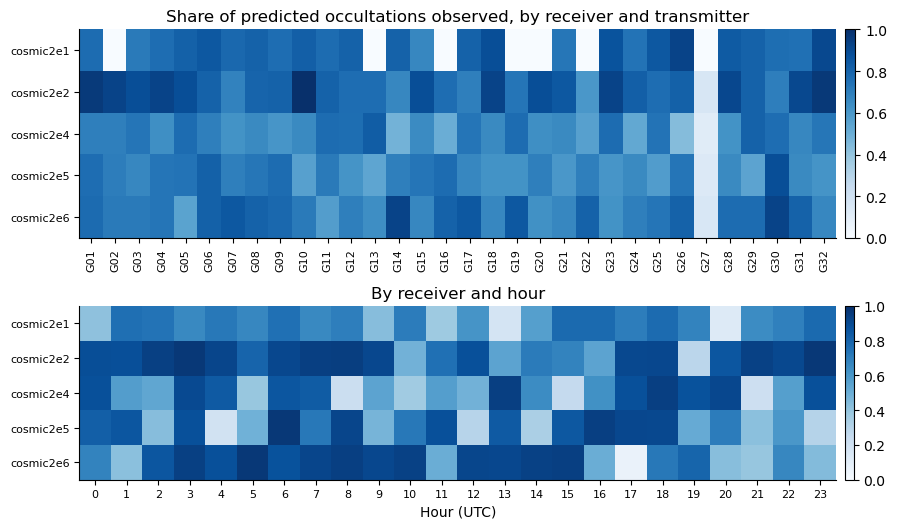

In [11]:
pred = predicted[65].copy()
pred["seen"] = False
pred.loc[pairs[65].pred, "seen"] = True
pred["yaw"] = folded(pred.rx_tx_yaw)
pred["hour"] = pred.time.dt.hour
pred["concurrent"] = [
    int(((pred.receiver == r.receiver) & (pred.is_rising == r.is_rising) & (pred.start < r.end) & (pred.end > r.start)).sum() - 1)
    for r in pred.itertuples()
]
by_pair = pred.pivot_table(index="receiver", columns="transmitter", values="seen", aggfunc="mean")
hourly = pred.groupby(["hour", "receiver"])["seen"].mean().unstack()  # hours x receivers

fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), gridspec_kw={"height_ratios": [1.2, 1]})
im = axes[0].imshow(by_pair.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(by_pair.shape[1]), by_pair.columns, rotation=90, fontsize=8)
axes[0].set_yticks(range(by_pair.shape[0]), by_pair.index, fontsize=8)
axes[0].grid(False)
axes[0].set_title("Share of predicted occultations observed, by receiver and transmitter")
fig.colorbar(im, ax=axes[0], pad=0.01)
im = axes[1].imshow(hourly.T.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(hourly.shape[0]), hourly.index, fontsize=8)
axes[1].set_yticks(range(hourly.shape[1]), hourly.columns, fontsize=8)
axes[1].grid(False)
axes[1].set(xlabel="Hour (UTC)", title="By receiver and hour")
fig.colorbar(im, ax=axes[1], pad=0.01)
fig.tight_layout()
plt.show()

Excluding the receiver-transmitter combinations that were never observed (below 10%), the remaining dependence on geometry and tracking load is:

In [12]:
seen_rate = pred.groupby(["receiver", "transmitter"])["seen"].transform("mean")
tracked = pred[seen_rate > 0.1]
groups = {
    # arcs cut off by the yaw limit report a yaw of exactly max_yaw (up to round-off)
    "yaw from fore/aft (deg)": pd.cut(tracked.yaw.clip(upper=65), [0, 15, 30, 45, 55, 60, 65]).astype(str),
    "direction": tracked.is_rising.map({True: "rising", False: "setting"}),
    "other same-direction occultations at the same time": tracked.concurrent.clip(upper=3).astype(str).replace("3", "3 or more"),
}
pd.concat(
    {name: tracked.groupby(key)["seen"].agg(["mean", "size"]) for name, key in groups.items()}
).rename(columns={"mean": "share observed", "size": "predicted"}).round(2)

share observed  \
yaw from fore/aft (deg)                            (0, 15]              0.77   
                                                   (15, 30]             0.77   
                                                   (30, 45]             0.76   
                                                   (45, 55]             0.73   
                                                   (55, 60]             0.67   
                                                   (60, 65]             0.15   
direction                                          rising               0.65   
                                                   setting              0.81   
other same-direction occultations at the same time 0                    0.75   
                                                   1                    0.73   
                                                   2                    0.68   
                                                   3 or more            0.59   

                                                              predicted  
yaw from fore/aft (deg)                            (0, 15]          923  
                                                   (15, 30]        1000  
                                                   (30, 45]        1002  
                                                   (45, 55]         436  
                                                   (55, 60]         140  
                                                   (60, 65]         190  
direction                                          rising          1850  
                                                   setting         1841  
other same-direction occultations at the same time 0               1468  
                                                   1               1634  
                                                   2                511  
                                                   3 or more         78

Most of the unrecorded predictions are explained by the receivers' operations rather than by geometry. Receiver cosmic2e1 recorded no occultations from seven PRNs (G02, G13, G16, G19, G20, G22, and G27) that the other receivers recorded normally, all receivers rarely recorded G27, and each receiver has hours with few or no recordings, apparently data gaps.

Among the remaining receiver-transmitter combinations, about three quarters of predicted occultations were recorded, nearly independent of yaw angle up to 55 deg, but only 15% between 60 and 65 deg, at the edge of the antenna's coverage. Setting occultations were recorded more often than rising ones (81% vs 65%), and the share decreases modestly when several occultations compete for the same receiver. These instrument and operations effects are outside TAT-C's geometric model: to estimate recorded rather than geometrically possible COSMIC-2 occultations, TAT-C's counts would need to be scaled by about 0.7.

## Test 7: Timing and Location of Matched Occultations

For matched occultations, TAT-C's `time` and `position` (at -80 km) are compared with the true straight-line tangent point from the recorded positions (for the sampled occultations), alongside the previous geocentric definition evaluated with the same orbits. Separately, every matched occultation's tangent point at -3 km, the straight-line height found in Test 3 to best match UCAR's reference location, is compared with that location under both definitions.

In [13]:
sampled = {o["occid"]: o for o in occs}
LABELS = {"ellipsoidal": "TAT-C (ellipsoidal)", "geocentric": "previous TAT-C (geocentric)"}
seconds = np.arange(-240.0, 240.0, 1.0)
rows = []
for i, j in zip(pairs[65].pred, pairs[65].obs):
    p, o = pred.loc[i], observed.loc[j]
    times = [p.time.to_pydatetime() + timedelta(seconds=s) for s in seconds]
    tle_points = tangent_points(
        ecf(satellites[p.receiver].orbit.to_gp_orbit(), times),
        ecf(satellites[p.transmitter].orbit.to_gp_orbit(), times),
        timescale.from_datetimes(times),
    )
    row = {}
    for k in ["geocentric", "ellipsoidal"]:
        tc = crossing(seconds, _geodetic_altitude(tle_points[k]), -3e3)
        if np.isfinite(tc):
            lon, lat, _ = to_lla(interpolate(seconds, tle_points[k], [tc]))
            row[f"{LABELS[k]}: -3 km point to UCAR reference location (km)"] = GEOD.inv(lon[0], lat[0], o.ref_lon, o.ref_lat)[2] / 1e3
    if o.occid in sampled:
        occ = sampled[o.occid]
        true_t80 = crossing(occ["t"], occ["lla"]["ellipsoidal"][2], -80e3)
        start = GPS_EPOCH + timedelta(seconds=occ["start"] - GPS_UTC_OFFSET)
        lon, lat, _ = to_lla(interpolate(occ["t"], occ["points"]["ellipsoidal"], [true_t80]))
        row["TAT-C time minus true time at -80 km (s)"] = (p.time.to_pydatetime() - start).total_seconds() - true_t80
        row["TAT-C position: -80 km point to truth (km)"] = GEOD.inv(p.position.x, p.position.y, lon[0], lat[0])[2] / 1e3
        tc = crossing(seconds, _geodetic_altitude(tle_points["geocentric"]), -80e3)
        lon_g, lat_g, _ = to_lla(interpolate(seconds, tle_points["geocentric"], [tc]))
        row["previous TAT-C (geocentric): -80 km point to truth (km)"] = GEOD.inv(lon_g[0], lat_g[0], lon[0], lat[0])[2] / 1e3
    rows.append(row)
accuracy = pd.DataFrame(rows)
accuracy.describe(percentiles=[0.5, 0.95]).T.round(3)

,count,mean,std,min,50%,95%,max
previous TAT-C (geocentric): -3 km point to UCAR reference location (km),2438.0,16.550,6.161,7.196,14.685,29.069,34.549
TAT-C (ellipsoidal): -3 km point to UCAR reference location (km),2438.0,13.379,1.416,11.128,12.967,16.373,22.544
TAT-C time minus true time at -80 km (s),199.0,-0.049,0.119,-0.499,-0.043,0.138,0.269
TAT-C position: -80 km point to truth (km),199.0,0.468,0.406,0.009,0.365,1.195,2.777
previous TAT-C (geocentric): -80 km point to truth (km),199.0,4.735,4.719,0.159,2.924,15.818,19.852


TAT-C's `time` agrees with the true time at which the straight line reaches -80 km to within 0.14 s (95th percentile), and its `position` with the true straight-line tangent point to 0.37 km (median) and 1.2 km (95th percentile), both limited only by orbit accuracy. The previous geocentric definition would have placed the same points 2.9 km (median) and 16 km (95th percentile) away. Against UCAR's reference location (using the -3 km point), the ellipsoidal definition gives 13.0 km (median) and 16 km (95th percentile), compared with 14.7 km and 29 km for the geocentric one, across all 2,438 matched occultations with a retrieval, consistent with Test 3.

## Summary

| Test | Result |
| --- | --- |
| 1. Size of the change | Horizontal shift of 3.0 km (median), 16 km (95th percentile), 21 km (maximum), largest near ±45 deg; height change under 33 m; time change under 0.02 s |
| 2. Operational convention (50-80 km) | Distance to UCAR's tangent points: ellipsoidal 0.18 km (median), geocentric 3.3 km, local center of curvature 3.9 km |
| 3. At the height matching UCAR's reference location (-3 km) | Distance to the reference location: ellipsoidal 12.8 km (median) and 16 km (95th percentile); geocentric 14.2 km and 28 km |
| 3. At the default `sample_elevation` (-80 km) | About 98 km from the reference location under either definition |
| 4. Orbits (TLEs vs. recorded positions) | Within about 5 km for all 32 GPS satellites and 5 receivers, after excluding one poor element set |
| 5. Predicted vs. observed (default `max_yaw` = 65 deg) | All 2,684 observed occultations predicted, with correct rising/setting; 69% of the 3,869 predicted occultations recorded |
| 6. Detection | Unrecorded predictions mostly explained by receiver operations (untracked PRNs, data gaps) and the antenna's coverage edge (60-65 deg yaw) |
| 7. Timing and location | `time` within 0.14 s (95th percentile); `position` 0.37 km (median) and 1.2 km (95th percentile) from the true tangent point, versus 2.9 km and 16 km with the previous geocentric definition |

**TAT-C's RO geometry is validated end to end.** With published orbits, `collect_ro_observations` predicts every GPS occultation COSMIC-2 recorded on this day, labels each correctly as rising or setting, and reports its time to a fraction of a second. The default `max_yaw` of 65 deg matches COSMIC-2's observed coverage: smaller values miss observed occultations, larger ones only add unrecorded predictions. Predicted counts are upper bounds on recorded counts: about 30% of the geometrically possible occultations were not recorded, for operational reasons outside TAT-C's model.

**TAT-C now uses the ellipsoidal tangent point.** Operational COSMIC-2 processing geolocates tangent points with the ellipsoidal definition, and the previous geocentric definition was the largest error in TAT-C's reported `position` (2.9 km median, 16 km at the 95th percentile). With the ellipsoidal definition, `position` agrees with the true straight-line tangent point to 0.37 km (median), limited by orbit accuracy. Heights and times change negligibly, so counts, timing, and the start and end of each occultation are unchanged (the predicted counts in Test 5 are identical under both definitions); only spatial results at scales of tens of kilometers change.

**Ray bending, not the definition, limits the representative point.** Even with the ellipsoidal definition, a straight-line model places the occultation about 13 km from UCAR's reference location, a nearly constant offset caused by ray bending. The default `sample_elevation` of -80 km represents the lowest troposphere, about 100 km from that reference location along the profile; a straight-line height of about -3 km reproduces it.

**Next steps:**

1. *Latitude coverage.* Repeat the study for a polar-orbiting RO mission in the AWS registry to cover high latitudes.
2. *Other constellations and processing centers.* Extend to GLONASS and Galileo transmitters and to other processing centers' geolocation conventions.
3. *More days.* Repeat on additional days to confirm that the detection share and `max_yaw` findings are stable.

**Limitations.** This study covers one day, UCAR processing only, and GPS transmitters only; Part 1 and the timing and truth comparisons of Test 7 use a random sample of 200 occultations.